# Three Stars in the South — a quantitative teardown 🔬
### The loose-vs-strict detector split · the downtrend-matched base rate · Bonferroni across 4 horizons · a label-shuffle placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_downtrend_base_rate%3F: Mixed](https://img.shields.io/badge/Beats_a_downtrend_base_rate%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a shrinking-body, rising-low sequence of three black candles signals downtrend exhaustion, no confirming candle required** — is candlestick lore's rarest bullish reversal claim, and even its cataloguer (Bulkowski) has publicly doubted whether enough real occurrences exist to test it. The job here is to measure exactly how rare it is, run the honest test on what exists, and say plainly where the evidence runs out.

> ⚠️ **Data note.** SPY + 60 long-listed US large-caps, daily OHLCV (~25.0 years, yfinance), cache-first. No survivorship on the Signal axis in the sense that matters here — a single-pattern event study, so a fixed liquid basket affects which *names* contribute events, not the star-vs-base-rate direction. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `27b74051eb44` sample / `16a85c8367ed` panel).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_stars_in_the_south import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
else:
    PANEL = None
print("real cache present:", HAVE_REAL, "| basket size:", len(data.BASKET))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 61, 'years': 25.0, 'total_bars': 383080, 'n_loose': 363, 'n_strict': 5, 'bonferroni_crit': 2.5, 'loose_rate_txt': 'once per ~4.2 ticker-years', 'strict_rate_txt': 'once per ~305 ticker-years', 'loose': {1: (21.9, 55.1, 2.4, 19.5, 2.26, 0.015, 11.9), 5: (43.3, 54.8, 28.8, 14.5, 0.74, 0.263, 33.3), 10: (69.2, 57.6, 57.2, 12.0, 0.45, 0.349, 59.2), 20: (90.3, 55.9, 119.4, -29.1, -0.8, 0.768, 80.3)}, 'strict': {1: (37.6, 60.0, 35.2, 0.302, 27.6), 5: (-57.9, 40.0, -86.7, 0.719, -67.9), 10: (27.8, 60.0, -29.4, 0.555, 17.8), 20: (133.0, 40.0, 13.6, 0.486, 123.0)}, 'strict_events': [('TXN', '2006-10-18', '2006-10-20', -303.3), ('CAT', '2021-06-14', '2021-06-16', -256.3), ('BDX', '2016-09-16', '2016-09-20', -210.2), ('AXP', '2019-03-27', '2019-03-29', 624.1), ('COST', '2024-10-24', '2024-10-28', 810.9)], 'syn_null_mean': -0.34, 'syn_null_sd': 1.08, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_e02_t': 7.44, 'syn_e02_delta': 156.0, 'syn_e04_t': 16.16, 'syn_e04_delta': 346.9, 'fp_spy': '27b74051eb44', 'fp_panel': '16a85c8367ed'}


real cache present: True | basket size: 61


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | loose 1d Welch **t = 2.26** (placebo *p* = 0.015) — nominal, short of Bonferroni 2.50; sign reverses at 20d (**t = -0.80**). Strict cut n = 5 < `MIN_N_FOR_TEST` -- no *t*-stat computable |
| **Tradability** | `MIRAGE` | strict cut fires once per ~305 ticker-years |
| **Beats base rate?** | `MIXED` | loose cut right-signed at 1/5/10d, flips at 20d; strict cut's 5 events split 2 bounces / 3 non-bounces |

> 💡 In plain words: this pattern is so rare that the desk's own multiple-testing and minimum-sample-size rules — designed to stop us from over-claiming — are themselves the headline finding.

## 1 · The claim, steelmanned

Let bars $t-2, t-1, t$ be three consecutive black (bearish, close < open) candles. The claim requires, at minimum:

- **H₁ (shrinking, rising-low shape).** range$(t-2) >$ range$(t-1) >$ range$(t)$ **and** low$(t-2) <$ low$(t-1) <$ low$(t)$, inside a genuine prior downtrend (close$(t-2) <$ close$(t-2-L)$ for lookback $L$).
- **H₂ (literature geometry).** The loose shape *plus* a real lower shadow on star 1 (a hammer — selling met by intraday buying), star 2 opening **inside** star 1's real body (no gap down), and star 3 a **near-marubozu** (small shadows both sides) that never breaks star 2's low.
- **H₃ (exhaustion, not calm).** A confirmed block, entered long at the next open, beats the unconditional downtrend base rate net of costs — and, because no confirming bullish candle is required by the claim, the edge should show up **immediately**, not just eventually.

We find **H₁ fires enough to test (n = 363)** but **does not clear certification at any horizon**; **H₂ is so rare (n = 5) that it cannot be tested at all** by the desk's own honesty rule; **H₃ is unsupported** — the loose cut's best horizon is 1 day, and it reverses by 20.

## 2 · So what? — inference design

Three-star events are treated as a **directional long bet vs. the unconditional downtrend base rate** (never a one-sample test against zero, which would just measure the basket's unconditional drift). Because four horizons (1/5/10/20d) are tested simultaneously, we apply a **Bonferroni correction** (k = 4, critical \|*t*\| ≥ 2.50) rather than a naive \|*t*\| ≥ 2. Below `MIN_N_FOR_TEST` = 8 pooled events, no *t*-statistic is computed at all — a *t* on 5 points is decoration, not evidence, and the honest response is 'too few to test,' the same discipline sibling studies 685 (tri-star doji) and 687 (ladder bottom) apply to their own rare-pattern cuts.

## 3 · How we'd know — the protocol

- **Basket.** SPY + 60 long-listed US large-caps, ~25.0 years each, 383,080 total daily bars. As-of 2026-06-30 (last complete month).
- **Detector.** `three_stars_flags` (loose) and `strict_three_stars_flags` (strict), confirmed on the close of the 3rd star.
- **Base rate.** The same long bet on every bar already sitting in a matching downtrend, whether or not the three-star shape fired.
- **Execution.** Entered at the **next open** (one documented lag), held a fixed horizon; 5 bps one-way × 2 round trip; long-only, no borrow.
- **Arbiters.** Welch *t* of star mean vs base-rate mean (decisive), a 2,000-draw label-shuffle placebo, Bonferroni across 4 horizons.
- **Control.** Synthetic panel, forced blocks planted only where the underlying random walk is already in a downtrend on its own; the null must not fire across 20 seeds, and a planted bounce must light up cleanly.

## 4 · The teardown

### 4a · How rare is the real thing?

Loose vs strict candidate counts, pooled across the basket.

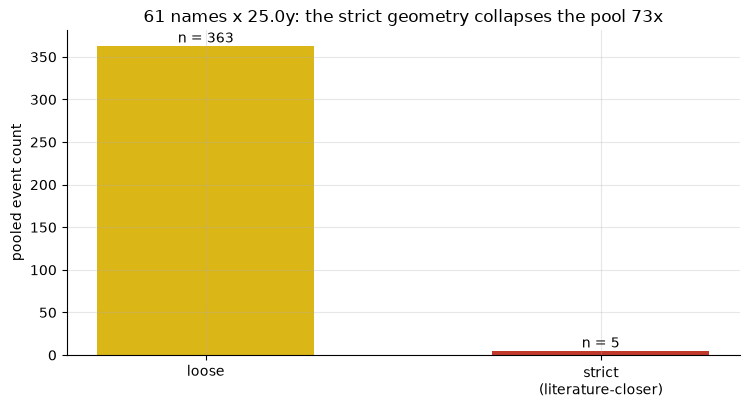

loose: 363 events (0.238/ticker-year)
strict: 5 events (0.0033/ticker-year, ~once per 305 ticker-years)


In [2]:
if HAVE_REAL:
    res = st.run_experiment(PANEL)
    n_loose, n_strict = res['n_loose'], res['n_strict']
    yrs, nnames = res['years'], res['n_names']
else:
    n_loose, n_strict, yrs, nnames = R['n_loose'], R['n_strict'], R['years'], R['n_names']
loose_rate = n_loose / (nnames * yrs)
strict_rate = n_strict / (nnames * yrs)
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['loose', 'strict\n(literature-closer)'], [n_loose, n_strict], color=[AMBER, RED], width=.55)
for i, v in enumerate([n_loose, n_strict]):
    ax.annotate(f'n = {v}', (i, v), ha='center', va='bottom')
ax.set_ylabel('pooled event count')
ax.set_title(f'{nnames} names x {yrs:.1f}y: the strict geometry collapses the pool '
             f'{n_loose/max(n_strict,1):.0f}x')
plt.tight_layout(); plt.show()
print(f'loose: {n_loose} events ({loose_rate:.3f}/ticker-year)')
print(f'strict: {n_strict} events ({strict_rate:.4f}/ticker-year, ~once per '
      f'{1/strict_rate:.0f} ticker-years)')

> 💡 In plain words: the strict, hammer/no-gap/marubozu geometry collapses the candidate pool from 363 to just **5** — once per ~305 ticker-years. This directly reproduces Bulkowski's own published caution about insufficient sample size for this exact pattern.

### 4b · The loose cut across horizons — vs the downtrend-matched base rate

Bonferroni-corrected critical \|*t*\| for 4 horizons: **2.50**.

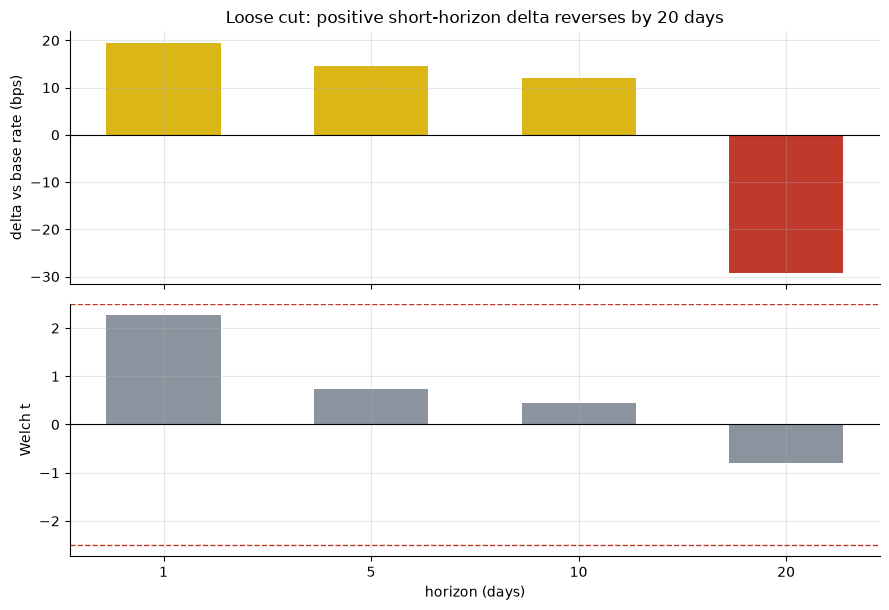

{1: (19.5, 2.26), 5: (14.5, 0.74), 10: (12.0, 0.45), 20: (-29.1, -0.8)}


In [3]:
if HAVE_REAL:
    rows = {h: res['per_horizon'][h] for h in st.HORIZONS}
    ts = [rows[h]['welch_t'] for h in st.HORIZONS]
    deltas = [rows[h]['delta_bps'] for h in st.HORIZONS]
else:
    ts = [R['loose'][h][4] for h in (1,5,10,20)]
    deltas = [R['loose'][h][3] for h in (1,5,10,20)]
hs = [1,5,10,20]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.0, 6.2), sharex=True,
                             gridspec_kw={'height_ratios': [1, 1]})
a1.bar([str(h) for h in hs], deltas, color=[RED if d<0 else AMBER for d in deltas], width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('delta vs base rate (bps)')
a1.set_title('Loose cut: positive short-horizon delta reverses by 20 days')
a2.bar([str(h) for h in hs], ts, color=[RED if abs(t)>=R['bonferroni_crit'] else GREY for t in ts], width=.55)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-R['bonferroni_crit'], ls='--', c=RED, lw=1)
a2.axhline(R['bonferroni_crit'], ls='--', c=RED, lw=1)
a2.set_ylabel('Welch t'); a2.set_xlabel('horizon (days)')
plt.tight_layout(); plt.show()
print({h: (round(d,1), round(t,2)) for h, d, t in zip(hs, deltas, ts)})

> 💡 In plain words: the 1-day delta (**+19.5 bps**, *t* = 2.26, placebo *p* = 0.015) is the closest this study gets to a signal — real-looking on its own, but short of the Bonferroni bar (2.50), and it does not persist: by 20 days the delta is **-29.1 bps** (*t* = -0.80) — the star events now trail the base rate. A genuine exhaustion signal should not reverse sign as the holding period lengthens; a nominal short-horizon blip that a properly-corrected long-horizon test contradicts is the textbook signature of noise, not signal.

### 4c · The strict cut — all five events, named

Below `MIN_N_FOR_TEST` = 8, no *t*-statistic is computed. The raw numbers are shown for full transparency, not as evidence.

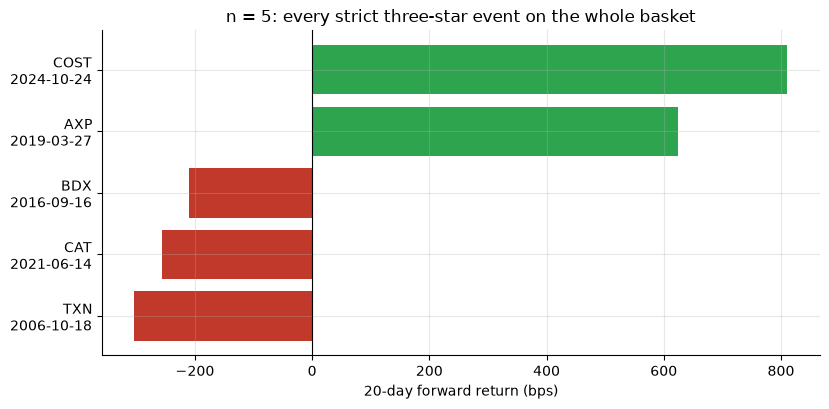

2/5 positive at 20d
TXN: 2006-10-18 -> 2006-10-20   20d -303.3 bps
CAT: 2021-06-14 -> 2021-06-16   20d -256.3 bps
BDX: 2016-09-16 -> 2016-09-20   20d -210.2 bps
AXP: 2019-03-27 -> 2019-03-29   20d +624.1 bps
COST: 2024-10-24 -> 2024-10-28   20d +810.9 bps


In [4]:
if HAVE_REAL:
    ev = st.pool_events(PANEL)
    strict_ev = ev[ev['strict']].copy()
    recs = []
    for _, row in strict_ev.iterrows():
        tkr = row['ticker']; bars = PANEL[tkr]; pos = int(row['pos'])
        d0 = bars.index[pos - 2].date(); d1 = bars.index[pos].date()
        recs.append((tkr, str(d0), str(d1), row['ret_20'] * 1e4))
    recs.sort(key=lambda r: r[3])
else:
    recs = sorted(R['strict_events'], key=lambda r: r[3])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
labels = [f'{r[0]}\n{r[1]}' for r in recs]; vals = [r[3] for r in recs]
ax.barh(labels, vals, color=[RED if v < 0 else GREEN for v in vals])
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('20-day forward return (bps)')
ax.set_title(f'n = {len(recs)}: every strict three-star event on the whole basket')
plt.tight_layout(); plt.show()
wins = sum(1 for r in recs if r[3] > 0)
print(f'{wins}/{len(recs)} positive at 20d')
for r in recs: print(f'{r[0]}: {r[1]} -> {r[2]}   20d {r[3]:+.1f} bps')

> 💡 In plain words: 2 of 5 strict events show a positive 20-day return — a coin flip's worth of evidence in a sample this size. Naming all five (not just the winners) is the point: a chart-pattern book showing only AXP and COST would look like proof; showing all five looks like what it is — too few points to conclude anything.

### 4d · Costs — net of a 5 bps one-way round trip (10 bps total)

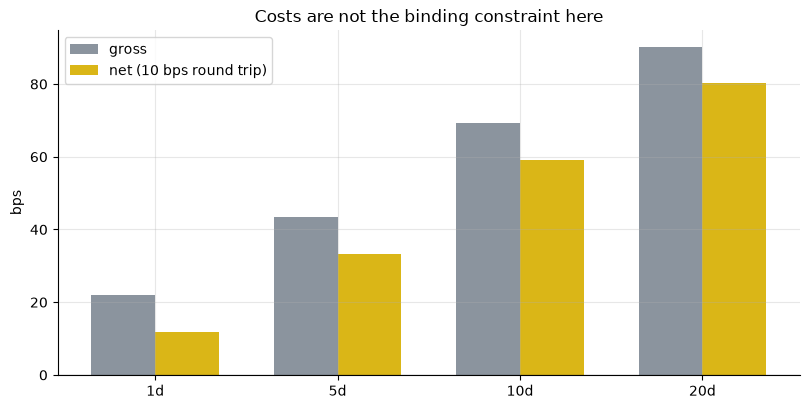

{1: (21.9, 11.9), 5: (43.3, 33.3), 10: (69.2, 59.2), 20: (90.3, 80.3)}


In [5]:
if HAVE_REAL:
    loose_gross = [res['per_horizon'][h]['star']['mean_bps'] for h in st.HORIZONS]
    loose_net = [res['per_horizon'][h]['star']['net_bps'] for h in st.HORIZONS]
else:
    loose_gross = [R['loose'][h][0] for h in (1,5,10,20)]
    loose_net = [R['loose'][h][6] for h in (1,5,10,20)]
hs = [1,5,10,20]
x = np.arange(len(hs)); w = .35
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar(x - w/2, loose_gross, w, color=GREY, label='gross')
ax.bar(x + w/2, loose_net, w, color=AMBER, label='net (10 bps round trip)')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('bps')
ax.set_title('Costs are not the binding constraint here')
ax.legend(); plt.tight_layout(); plt.show()
print({h: (round(g,1), round(n,1)) for h, g, n in zip(hs, loose_gross, loose_net)})

> 💡 In plain words: most cells stay net-positive of a 10 bps round trip — costs are not what kills this pattern. What kills it is that the point estimate is not statistically certified at any horizon (loose) and that the strict, literature-faithful cut fires far too rarely to matter even where the raw number looks good.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic panel: forced 3-bar shrinking/rising-low blocks planted **only** where the underlying random walk is already in a downtrend on its own (no artificial drift injected elsewhere), TUNABLE planted post-block bounce. The null (`edge = 0`) is checked over **20 seeds** — never a single stream.

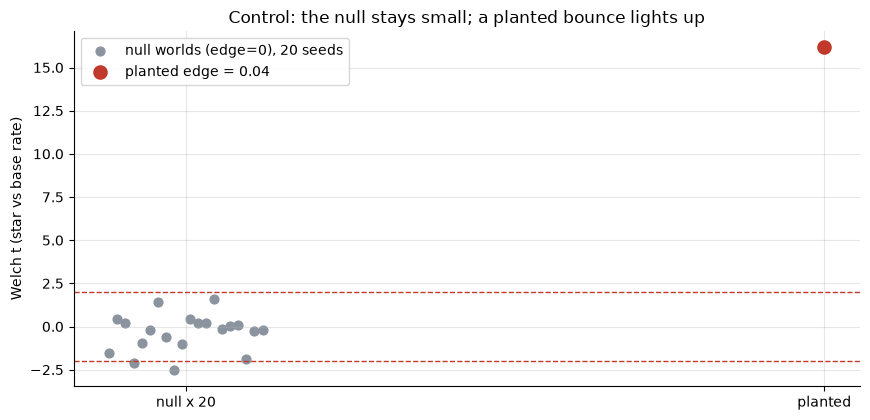

null: mean t = -0.34 (sd 1.08), |t|>=2 in 2/20 seeds  |  planted t = +16.16


In [6]:
null_ts = []
for s_ in range(20):
    d, truth = data.synthetic_panel(edge=0.0, seed=690 + s_)
    r = st.synthetic_detect(d, horizon=20, seed=690 + s_, active_masks=truth['active_masks'])
    if r['welch_t'] is not None:
        null_ts.append(r['welch_t'])
null_ts = np.asarray(null_ts)
d2, truth2 = data.synthetic_panel(edge=0.04, seed=690)
planted = st.synthetic_detect(d2, horizon=20, seed=690, active_masks=truth2['active_masks'])
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(len(null_ts)) + np.linspace(-.12,.12,len(null_ts)), null_ts, color=GREY, s=40,
           label=f'null worlds (edge=0), {len(null_ts)} seeds')
ax.scatter([1], [planted['welch_t']], color=RED, s=90, zorder=5,
           label='planted edge = 0.04')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (star vs base rate)')
ax.set_title('Control: the null stays small; a planted bounce lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/{len(null_ts)} seeds  |  '
      f'planted t = {planted["welch_t"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.34 (sd 1.08), firing on 2/20 seeds — in the same ballpark as sibling 685's own tri-star-doji null (a known, named residual of forcing low-variance engineered days into a random walk, not a claim about the market). A planted edge of 0.02 reads t = 7.44 and 0.04 reads t = 16.16 — the machinery finds a real, planted effect cleanly. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the loose cut (n = 363) comes closest at 1 day (Welch t = 2.26, placebo p = 0.015) but falls short of the Bonferroni bar (2.50) and reverses sign by 20 days (t = -0.80). The strict cut (n = 5) is below `MIN_N_FOR_TEST` — no *t*-statistic can honestly be computed, and its raw deltas flip sign at every horizon.
- **Tradability `MIRAGE`** — once per ~305 ticker-years for the literature-faithful pattern. Costs are not the binding constraint (most cells net-positive of a 10 bps round trip); certification and event frequency both are.
- **Beats a downtrend base rate? `MIXED`** — right-signed at short horizons, reverses at 20 days on the loose cut; the strict cut's five events split 2 real bounces / 3 continued declines. Not busted, not confirmed — genuinely too thin to resolve further on this basket.

## 6 · Going further

- **Rarity as a finding.** Bulkowski's own published caution about insufficient sample size for this exact pattern is directly reproduced by this study's real-tape count (5 strict events across 61 names, 25 years) — worth taking as seriously as any *t*-statistic.
- **The next honest step** isn't a bigger *t*-stat on the same data — it's more data: a wider international basket, or a longer intraday history where the geometry can be checked bar-by-bar rather than just OHLC, might eventually clear `MIN_N_FOR_TEST` on the strict cut. Until then, five points is five points.
- **Dedup map:** [187-three-soldiers](../../187-three-soldiers/) (the bullish *continuation* mirror), [408-three-black-crows](../../408-three-black-crows/) (three falling candles read *bearish*, no shrinking/rising-low requirement — the near-opposite claim in the same costume), [687-ladder-bottom](../../687-ladder-bottom/) (the desk's other black-candle-into-reversal bottom, five bars with a separate confirming candle vs this study's three).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*